# Лабораторная работа. Ансамбли моделей машинного обучения. Часть 2.

## 1. Цель лабораторной работы:
Изучение ансамблей моделей машинного обучения, их практического применения и оценка качества. Особое внимание уделяется методам стекинга, нейронным сетям (многослойный персептрон) и ансамблевым методам, схожим по концепции с МГУА, для решения задачи регрессии.

## 2. Введение в ансамбли моделей машинного обучения
Ансамбли моделей — это мощный подход в машинном обучении, который заключается в объединении предсказаний нескольких базовых моделей для повышения общей производительности. Основная идея состоит в том, что группа "слабых" моделей, если они правильно скомбинированы, может дать "сильную" модель, превосходящую любую из отдельных составляющих. Этот подход помогает уменьшить переобучение, смещение и дисперсию, делая модели более устойчивыми и точными.

### 2.1. Преимущества ансамблей:
* **Повышенная точность:** Комбинирование различных моделей может усреднить ошибки и улучшить общую предсказательную способность.
* **Снижение переобучения:** Разнообразие моделей в ансамбле помогает уменьшить риск переобучения на конкретном обучающем наборе данных.
* **Устойчивость:** Ансамблевые методы менее чувствительны к шуму в данных и аномалиям.

### 2.2. Основные стратегии ансамблирования:
1.  **Бэггинг (Bagging - Bootstrap Aggregating):** Создание нескольких версий одной и той же модели путем обучения их на разных подвыборках исходных данных (полученных с помощью бутстрапа). Предсказания затем усредняются (для регрессии) или используется голосование (для классификации). Примеры: Random Forest, Bagging Regressor.
    * **Математическая модель:** Если есть $B$ базовых моделей $h_1, ..., h_B$, обученных на бутстрап-выборках, то итоговое предсказание для регрессии: $H(x) = \frac{1}{B} \sum_{i=1}^B h_i(x)$.

2.  **Бустинг (Boosting):** Последовательное построение моделей, где каждая последующая модель пытается исправить ошибки предыдущих. Модели обучаются и добавляются к ансамблю пошагово, улучшая общую производительность. Примеры: AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost.
    * **Математическая модель (Gradient Boosting):** Итеративно строит аддитивную модель $F(x) = \sum_{m=1}^M \gamma_m h_m(x)$, где каждая $h_m(x)$ обучается на остатках (градиентах) предыдущей модели, чтобы минимизировать функцию потерь.

3.  **Стекинг (Stacking - Stacked Generalization):** Создание многоуровневой системы, где базовые модели (уровень 0) обучаются на исходных данных, а затем мета-модель (уровень 1) обучается на *предсказаниях* базовых моделей. Это позволяет мета-модели "учиться" комбинировать предсказания базовых моделей оптимальным образом.
    * **Математическая модель:** Пусть $h_1, ..., h_K$ - базовые модели. Их предсказания на обучающем наборе $D_{train}$ формируют новый набор признаков $X'_{train} = [h_1(X_{train}), ..., h_K(X_{train})]$. Мета-модель $g$ обучается на $(X'_{train}, y_{train})$. Для предсказания на тестовом наборе: $H(x_{test}) = g([h_1(x_{test}), ..., h_K(x_{test})])$.

4.  **Многослойный персептрон (MLP):** Хотя формально не является ансамблем в том же смысле, что бэггинг или бустинг, MLP — это фундаментальная нейронная сеть, которая может быть использована как самостоятельная мощная модель или как компонент в более сложных ансамблевых архитектурах (например, в стекинге или для извлечения признаков для других моделей). MLP имитирует работу человеческого мозга и способен обучаться сложным нелинейным зависимостям в данных.
    * **Математическая модель:** MLP состоит из входного слоя, одного или нескольких скрытых слоев и выходного слоя. Каждый нейрон в скрытом слое вычисляет взвешенную сумму своих входов, пропускает ее через функцию активации (например, ReLU, сигмоида), и передает результат на следующий слой. Для нейрона $j$ в слое $l$: $a_j^{(l)} = f(\sum_i w_{ji}^{(l)} a_i^{(l-1)} + b_j^{(l)})$, где $f$ - функция активации.

5.  **Методы Группового Учета Аргументов (МГУА):** Семейство методов машинного обучения, разработанное академиком А.Г. Ивахненко, которые строят модель путем послойного отбора оптимальных полиномиальных уравнений на основе принципа самоорганизации и использования внешних критериев (например, критерия регулярности). Эти методы итеративно генерируют новые признаки и выбирают наилучшие комбинации, создавая сложную модель из простых элементов. Зачастую это последовательное построение слоев полиномиальных моделей.
    * **Логическая модель:** МГУА строит модель "снизу вверх", начиная с простых преобразований исходных признаков, а затем комбинируя их в более сложные полиномы. На каждом слое оценивается множество комбинаций, и отбираются только те, которые улучшают некоторый внешний критерий (например, точность на отложенной выборке).
    * **Математическая модель (обобщенно):** На каждом слое $k$, входные переменные $x_i, x_j$ преобразуются в частичные описания вида $y = a_0 + a_1 x_i + a_2 x_j + a_3 x_i x_j + a_4 x_i^2 + a_5 x_j^2$ (для квадратичного полинома). Множество таких функций генерируется, и лучшие из них (по внешнему критерию) становятся входами для следующего слоя.
    * **Примечание:** В данной работе библиотека `gmdh` была заменена на аналоги из `scikit-learn` из-за проблем с совместимостью на macOS. В качестве аналогов были выбраны `GradientBoostingRegressor` (как метод последовательного построения) и `BaggingRegressor` (как метод ансамблирования, создающий комитет моделей).

## 3. Задание:
1. Выбрать набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости провести удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода `train_test_split` разделить выборку на обучающую и тестовую.
4. Обучить следующие ансамблевые модели:
    - Одну из моделей группы стекинга.
    - Модель многослойного персептрона. По желанию, вместо библиотеки scikit-learn возможно использование библиотек TensorFlow, PyTorch или других аналогичных библиотек.
    - Двумя методами на выбор из семейства МГУА (один из линейных методов COMBI / MULTI + один из нелинейных методов MIA / RIA) с использованием библиотеки `gmdh`. (Заменено на аналоги из scikit-learn, так как `gmdh` не работает на Mac).
5. Оценить качество моделей с помощью одной из подходящих для задачи метрик. Сравнить качество полученных моделей.

## 4. Установка необходимых библиотек
Перед началом работы необходимо установить все необходимые библиотеки. Команда `!pip install` выполняет установку пакетов в текущем окружении Jupyter.

In [1]:
# Установка основных библиотек для обработки данных и машинного обучения
# pandas: для работы с табличными данными (DataFrame)
# scikit-learn: для предобработки данных, разделения выборок, построения моделей и оценки качества
# numpy: для численных операций
# matplotlib, seaborn: для визуализации данных и результатов
# mlxtend: для некоторых продвинутых ансамблевых методов (хотя StackingRegressor теперь в scikit-learn)
# tensorflow: для построения и обучения нейронных сетей (Многослойный персептрон)
# tabulate: для форматированного вывода таблиц (используется pandas.to_markdown)
!pip install pandas scikit-learn numpy matplotlib seaborn mlxtend tensorflow tabulate

  Using cached scikit_learn-1.7.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.0-cp311-cp311-macosx_12_0_arm64.whl (10.7 MB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn]━━━━━ 2/3 [scikit-learn]


## 5. Выбор и предобработка данных
В качестве датасета для решения задачи регрессии выберем [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices). Этот датасет содержит информацию о ценах на жилье в различных районах Калифорнии и является классическим бенчмарком для регрессионных задач.

**Логика предобработки:**
1.  **Загрузка данных:** Попытка загрузить данные из локального файла `housing.csv`. Если файл не найден (например, при запуске на платформе без предварительной загрузки данных), датасет будет загружен из библиотеки `scikit-learn`.
2.  **Разделение на признаки и целевую переменную:** Целевая переменная `MedHouseVal` (медианная стоимость жилья) отделяется от остальных признаков.
3.  **Идентификация типов признаков:** Признаки делятся на числовые и категориальные для применения специфичной предобработки.
4.  **Пайплайны предобработки:**
    * **Числовые признаки:** Пропуски заполняются средним значением (`SimpleImputer(strategy='mean')`), а затем данные масштабируются (`StandardScaler`) для приведения их к стандартному нормальному распределению (среднее 0, дисперсия 1). Это важно для многих моделей, особенно для нейронных сетей и линейных моделей.
    * **Категориальные признаки:** Пропуски заполняются наиболее частым значением (`SimpleImputer(strategy='most_frequent')`), а затем применяется One-Hot кодирование (`OneHotEncoder`). One-Hot кодирование преобразует категориальные признаки в числовой формат, создавая новые бинарные признаки для каждой категории, что необходимо для большинства алгоритмов машинного обучения.
5.  **`ColumnTransformer`:** Объединяет пайплайны для числовых и категориальных признаков, применяя их к соответствующим столбцам данных.
6.  **Разделение на обучающую и тестовую выборки:** Данды делятся на обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) части в соотношении 80/20. Это позволяет оценить обобщающую способность модели на данных, которые она не видела в процессе обучения.
7.  **Применение предобработки:** Пайплайн `preprocessor` обучается на обучающей выборке (`fit_transform`) и затем применяется к тестовой выборке (`transform`) для обеспечения консистентности и предотвращения утечки данных из тестовой выборки.
8.  **Преобразование в плотный массив:** Для TensorFlow моделей, которые ожидают плотные массивы (а не разреженные матрицы, которые могут быть результатом `OneHotEncoder`), выполняется принудительное преобразование `.toarray()`.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Загрузка данных
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True) # Загружаем данные как Pandas DataFrame
data = housing.frame

# Просмотр общей информации о данных (типы данных, количество пропусков)
print("Информация о датасете:")
data.info()

# Просмотр первых нескольких строк датасета
print("\nПервые 5 строк датасета:")
print(data.head())

# 2. Разделение на признаки (X) и целевую переменную (y)
X = data.drop('MedHouseVal', axis=1) # Признаки
y = data['MedHouseVal'] # Целевая переменная (медианная стоимость жилья)

# 3. Определение числовых и категориальных признаков
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# 4. Создание пайплайнов для предобработки
# Пайплайн для числовых признаков: заполнение пропусков (средним) и масштабирование (StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Заполнение пропусков средним
    ('scaler', StandardScaler()) # Стандартизация данных (среднее = 0, стандартное отклонение = 1)
])

# Пайплайн для категориальных признаков: заполнение пропусков (наиболее частым) и One-Hot кодирование
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Заполнение пропусков наиболее частым значением
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-Hot кодирование, игнорирование неизвестных категорий
])

# 5. Объединение пайплайнов для всех признаков с использованием ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features), # Применяем 'num' пайплайн к числовым признакам
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Разделение данных на обучающую и тестовую выборки
# test_size=0.2 означает, что 20% данных пойдут на тестовую выборку, 80% на обучающую
# random_state=42 обеспечивает воспроизводимость результатов разделения
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Применение предобработки к обучающей и тестовой выборкам
# fit_transform() обучается на X_train и преобразует его
# transform() использует параметры, обученные на X_train, и преобразует X_test (без обучения на X_test, чтобы избежать утечки данных)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 8. **Критическое исправление для TensorFlow:**
# Убедимся, что данные являются плотными (dense) массивами numpy.
# OneHotEncoder может возвращать разреженные матрицы, которые TensorFlow не может напрямую использовать.
if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()
    print("Преобразована X_train_processed из разреженной матрицы в плотный массив.")
if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()
    print("Преобразована X_test_processed из разреженной матрицы в плотный массив.")

print(f"\nРазмерность обучающей выборки после предобработки: {X_train_processed.shape}, Тип: {type(X_train_processed)}")
print(f"Размерность тестовой выборки после предобработки: {X_test_processed.shape}, Тип: {type(X_test_processed)}")


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Первые 5 строк датасета:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073

## 6. Моделирование и оценка
На этом этапе будут обучены и оценены различные ансамблевые модели и многослойный персептрон. Для оценки качества моделей регрессии будут использоваться следующие метрики:

* **Среднеквадратичная ошибка (Mean Squared Error, MSE)**: $MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$
    * Описывает среднюю квадратичную разницу между истинными ($y_i$) и предсказанными ($\hat{y}_i$) значениями. Чем меньше MSE, тем лучше модель.
    * **Логическая модель:** Большие ошибки наказываются сильнее, чем маленькие, благодаря возведению в квадрат. Это делает MSE чувствительной к выбросам.

* **Коэффициент детерминации ($R^2$ Score)**: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$
    * Показывает, какую долю дисперсии целевой переменной объясняет модель. Значение 1 означает идеальное предсказание, 0 - модель не лучше предсказания среднего значения. Отрицательные значения указывают на то, что модель хуже, чем простое предсказание среднего.
    * **Логическая модель:** $R^2$ сравнивает ошибки вашей модели с ошибками базовой модели, которая всегда предсказывает среднее значение целевой переменной. Это позволяет оценить относительное качество модели.

### 6.1. Модель стекинга (Stacking Regressor)
**Логическая модель:** Stacking - это мета-обучающий подход, который учится, как оптимально комбинировать предсказания нескольких базовых моделей. На первом уровне (уровень 0) обучаются несколько разнообразных базовых моделей на обучающих данных. Затем их предсказания на *отложенной* части обучающих данных (или с использованием кросс-валидации) используются в качестве новых признаков для обучения мета-модели (уровень 1). Мета-модель учится взвешивать или преобразовывать эти предсказания для получения окончательного вывода.

**Математическая модель:**
1.  **Базовые модели ($h_1, ..., h_K$):** Каждая модель $h_k$ обучается на части обучающих данных и делает предсказания $P_k(x)$.
2.  **Генерация мета-признаков:** Для каждого объекта $x_i$ из обучающей выборки, каждая базовая модель $h_k$ делает предсказание $\hat{y}_{ik}$. Эти предсказания формируют новый набор признаков для мета-модели: $X'_{train} = [P_1(X_{train}), P_2(X_{train}), ..., P_K(X_{train})]$. Важно использовать кросс-валидацию при получении этих предсказаний, чтобы избежать утечки данных.
3.  **Мета-модель ($g$):** Обучается на новых признаках $X'_{train}$ и исходных целевых значениях $y_{train}$. Таким образом, $g$ учится, как комбинировать предсказания базовых моделей.
4.  **Финальное предсказание:** Для нового объекта $x_{test}$, базовые модели делают предсказания $P_k(x_{test})$. Эти предсказания затем передаются мета-модели для получения окончательного вывода: $\hat{y}_{final} = g([P_1(x_{test}), P_2(x_{test}), ..., P_K(x_{test})])$.

В данном случае, в качестве базовых моделей используются `LinearRegression`, `DecisionTreeRegressor` и `KNeighborsRegressor`, а в качестве мета-модели - `LinearRegression`. Кросс-валидация (`cv=5`) применяется для генерации признаков для мета-модели.

In [3]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Базовые модели (estimators) для стекинга
# Выбираем разнообразные модели, чтобы они дополняли друг друга
estimators = [
    ('lr', LinearRegression()), # Простая, но эффективная линейная модель
    ('dt', DecisionTreeRegressor(random_state=42)), # Нелинейная модель, хорошо работает с взаимодействиями признаков
    ('knn', KNeighborsRegressor()) # Модель, основанная на схожести, без явных параметров
]

# Мета-модель (final_estimator), которая будет обучаться на предсказаниях базовых моделей
# Линейная регрессия часто используется как простая и интерпретируемая мета-модель
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(), # Мета-модель
    cv=5 # Количество фолдов для кросс-валидации при обучении базовых моделей на тренировочных данных
)

# Обучение StackingRegressor на предобработанных обучающих данных
print("\nНачинаем обучение StackingRegressor...")
stacking_regressor.fit(X_train_processed, y_train)
print("Обучение StackingRegressor завершено.")

# Предсказания на тестовой выборке
y_pred_stacking = stacking_regressor.predict(X_test_processed)

# Оценка качества модели StackingRegressor
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

print(f"\nStacking Regressor MSE: {mse_stacking:.4f}")
print(f"Stacking Regressor R2: {r2_stacking:.4f}")



Начинаем обучение StackingRegressor...
Обучение StackingRegressor завершено.

Stacking Regressor MSE: 0.3406
Stacking Regressor R2: 0.7401


### 6.2. Модель многослойного персептрона (MLP) с использованием TensorFlow
**Логическая модель:** Многослойный персептрон (MLP) — это класс прямых нейронных сетей, состоящих как минимум из трех слоев нейронов: входного слоя, одного или нескольких скрытых слоев и выходного слоя. Нейроны в каждом слое соединены с нейронами в следующем слое, но не имеют соединений внутри своего слоя или с предыдущими слоями. MLP использует нелинейные функции активации, что позволяет ему обучаться сложным нелинейным зависимостям в данных. Обучение происходит методом обратного распространения ошибки (backpropagation) и градиентного спуска.

**Математическая модель:**
Для каждого нейрона $j$ в скрытом слое $l$, выход $a_j^{(l)}$ вычисляется как:
$z_j^{(l)} = \sum_{i} w_{ji}^{(l)} a_i^{(l-1)} + b_j^{(l)}$
$a_j^{(l)} = f(z_j^{(l)})$ 
где:
* $a_i^{(l-1)}$ - выход нейрона $i$ из предыдущего слоя $(l-1)$.
* $w_{ji}^{(l)}$ - вес связи от нейрона $i$ в слое $(l-1)$ к нейрону $j$ в слое $l$.
* $b_j^{(l)}$ - смещение (bias) нейрона $j$ в слое $l$.
* $f$ - функция активации (в данном случае ReLU, $f(x) = \max(0, x)$).

Для выходного слоя в задаче регрессии обычно используется линейная функция активации (или её отсутствие, что эквивалентно). Модель обучается минимизировать функцию потерь (MSE) с использованием оптимизатора (Adam), который адаптирует скорости обучения для каждого веса.

**Архитектура модели:**
* **Входной слой:** Автоматически определяется по `input_shape` первого `Dense` слоя. Размерность совпадает с количеством признаков после предобработки.
* **Скрытые слои:** Три `Dense` слоя с 128, 64 и 32 нейронами соответственно, с функцией активации `relu`. `relu` (Rectified Linear Unit) - популярная функция активации, которая помогает решать проблему затухающих градиентов.
* **Выходной слой:** Один `Dense` нейрон (для регрессии).
* **Компиляция:** Используется оптимизатор `Adam` (популярный и эффективный), функция потерь `mse` (среднеквадратичная ошибка), и метрика `mae` (средняя абсолютная ошибка) для отслеживания прогресса.
* **Обучение:** Модель обучается в течение 100 эпох с размером батча 32 и использованием 10% обучающей выборки для валидации.

In [4]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.optimizers import Adam

# # Создание модели MLP (Multilayer Perceptron)
# model_mlp = Sequential([
#     # Первый скрытый слой с 128 нейронами и активацией ReLU
#     # input_shape=(X_train_processed.shape[1],) указывает размерность входных данных (количество признаков)
#     Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
#     # Второй скрытый слой с 64 нейронами и активацией ReLU
#     Dense(64, activation='relu'),
#     # Третий скрытый слой с 32 нейронами и активацией ReLU
#     Dense(32, activation='relu'),
#     # Выходной слой с 1 нейроном для задачи регрессии. Линейная активация по умолчанию.
#     Dense(1)
# ])

# # Компиляция модели
# # optimizer=Adam(learning_rate=0.001): Адаптивный оптимизатор с заданной скоростью обучения.
# # loss='mse': Функция потерь - Mean Squared Error, стандартная для регрессии.
# # metrics=['mae']: Метрика для отслеживания в процессе обучения - Mean Absolute Error.
# model_mlp.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# # Обучение модели MLP
# print("\nНачинаем обучение MLP...")
# history_mlp = model_mlp.fit(
#     X_train_processed, y_train, # Обучающие данные
#     epochs=100, # Количество полных проходов по всему обучающему набору данных
#     batch_size=32, # Количество образцов для одного обновления градиента
#     validation_split=0.1, # 10% данных из X_train_processed будут использованы для валидации
#     verbose=1 # Вывод прогресса обучения (0 - без вывода, 1 - прогресс бар, 2 - одна строка на эпоху)
# )
# print("Обучение MLP завершено.\n")

# # Оценка модели на тестовой выборке
# # evaluate() возвращает потери и метрики, указанные при компиляции
# loss_mlp, mae_mlp = model_mlp.evaluate(X_test_processed, y_test, verbose=0)

# # Предсказания на тестовой выборке
# # .predict() возвращает массив предсказаний, .flatten() преобразует его в одномерный массив
# y_pred_mlp = model_mlp.predict(X_test_processed).flatten()

# # Расчет MSE и R2 Score для MLP
# mse_mlp = mean_squared_error(y_test, y_pred_mlp)
# r2_mlp = r2_score(y_test, y_pred_mlp)

# print(f"MLP MSE: {mse_mlp:.4f}")
# print(f"MLP R2: {r2_mlp:.4f}")


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Масштабирование входов
scaler_X = StandardScaler()
X_train_processed = scaler_X.fit_transform(X_train)
X_test_processed = scaler_X.transform(X_test)

# Масштабирование целей (если значения большие)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.to_numpy().reshape(-1, 1)).flatten()

# Создание модели
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Обучение модели
history = model.fit(
    X_train_processed, y_train_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Обучение MLP завершено.\n")

# Предсказания (в масштабе StandardScaler)
y_pred_mlp_scaled = model.predict(X_test_processed).flatten()

# Обратное преобразование предсказаний в исходный масштаб
y_pred_mlp = scaler_y.inverse_transform(y_pred_mlp_scaled.reshape(-1, 1)).flatten()

# Расчёт метрик на предсказаниях в исходном масштабе
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print(f"MLP MSE: {mse_mlp:.4f}")
print(f"MLP R2: {r2_mlp:.4f}")


Epoch 1/100


/Volumes/university/education/6 term/tmo/labs/lab 6/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-18 13:22:47.289679: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-06-18 13:22:47.289712: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-06-18 13:22:47.289717: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-06-18 13:22:47.289746: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-06-18 13:22:47.289755: I tensorflow/core/common_runtime/pluggable_device/pluggable_

465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.0550 - mae: 0.7437 - val_loss: 0.5270 - val_mae: 0.5306
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.7649 - mae: 0.6196 - val_loss: 0.4931 - val_mae: 0.5110
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6191 - mae: 0.5795 - val_loss: 0.4727 - val_mae: 0.4999
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.6284 - mae: 0.5618 - val_loss: 0.4674 - val_mae: 0.4993
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.5722 - mae: 0.5557 - val_loss: 0.4618 - val_mae: 0.4959
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.6246 - mae: 0.5505 - val_loss: 0.4573 - val_mae: 0.4922
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5422 - mae: 0.5422 - val_loss: 0.4486 - val_mae: 0.4894
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.5350 - mae: 0.5309 - val_loss: 0.4354 - val_mae: 0.4782
Epoch 9/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - los

### 6.3. Модели, аналогичные МГУА (для Mac)
Как упоминалось ранее, библиотека `gmdh` может иметь проблемы с совместимостью на некоторых операционных системах, включая macOS. В связи с этим, для выполнения задачи, мы используем два мощных ансамблевых метода из `scikit-learn`, которые в некотором смысле отражают принципы МГУА: построение сложных моделей из простых компонентов или последовательное улучшение.

#### 6.3.1. Gradient Boosting Regressor (аналог последовательного построения)
**Логическая модель:** Gradient Boosting строит модель итеративно, добавляя новые слабые предсказательные модели (обычно деревья решений), которые компенсируют ошибки предыдущих моделей. На каждой итерации модель обучается на остатках (или градиентах) предыдущих моделей, пытаясь уменьшить ошибку. Это напоминает послойное наращивание сложности в МГУА, где каждый следующий слой улучшает предсказания предыдущего.

**Математическая модель:** Модель $F_M(x)$ строится как аддитивная сумма $M$ слабых моделей $h_m(x)$:
$F_M(x) = \sum_{m=1}^M \gamma_m h_m(x)$
На каждой итерации $m$, $h_m(x)$ обучается на отрицательном градиенте функции потерь по отношению к предсказаниям $F_{m-1}(x)$:
$r_{im} = -[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}]_{F(x)=F_{m-1}(x)}$
где $L$ - функция потерь (для регрессии часто MSE). Затем находится оптимальный коэффициент $\gamma_m$ для $h_m(x)$.

#### 6.3.2. Bagging Regressor (аналог комитета моделей)
**Логическая модель:** Bagging (Bootstrap Aggregating) строит ансамбль из нескольких независимых базовых моделей. Каждая базовая модель обучается на своей собственной подвыборке данных, полученной с помощью бутстрапа (выборка с возвращением из исходного набора). Предсказания всех базовых моделей затем усредняются (для регрессии), чтобы получить окончательный вывод. Это схоже с идеей МГУА о формировании "комитета" моделей, где разнообразие достигается за счет обучения на разных данных.

**Математическая модель:** Если есть $B$ базовых моделей $h_1, ..., h_B$, каждая обученная на бутстрап-выборке $D_b$ из исходного набора данных $D$. Тогда для регрессии, итоговое предсказание для нового объекта $x$ вычисляется как среднее арифметическое предсказаний всех базовых моделей:
$H(x) = \frac{1}{B} \sum_{b=1}^B h_b(x)$

In [6]:
from sklearn.ensemble import GradientBoostingRegressor, BaggingRegressor

# Метод 1: Gradient Boosting Regressor
# n_estimators: Количество бустинг-стадий (количество деревьев).
# learning_rate: Темп, с которым вклад каждого дерева уменьшается. Маленькие значения требуют больше деревьев.
# max_depth: Максимальная глубина индивидуальных регрессионных оценок.
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

print("\nНачинаем обучение GradientBoostingRegressor...")
gbr.fit(X_train_processed, y_train)
print("Обучение GradientBoostingRegressor завершено.")

y_pred_gbr = gbr.predict(X_test_processed)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"\nGradient Boosting Regressor MSE: {mse_gbr:.4f}")
print(f"Gradient Boosting Regressor R2: {r2_gbr:.4f}")

# Метод 2: Bagging Regressor
# estimator: Базовая модель для обучения (здесь DecisionTreeRegressor).
# n_estimators: Количество базовых моделей в ансамбле.
# n_jobs=-1: Использовать все доступные ядра процессора для параллельного обучения базовых моделей.
bagging_regressor = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42), # Базовая модель
    n_estimators=100, # Количество базовых моделей
    random_state=42,
    n_jobs=-1 # Использовать все доступные ядра процессора
)

print("\nНачинаем обучение BaggingRegressor...")
bagging_regressor.fit(X_train_processed, y_train)
print("Обучение BaggingRegressor завершено.")

y_pred_bagging = bagging_regressor.predict(X_test_processed)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)

print(f"\nBagging Regressor MSE: {mse_bagging:.4f}")
print(f"Bagging Regressor R2: {r2_bagging:.4f}")



Начинаем обучение GradientBoostingRegressor...
Обучение GradientBoostingRegressor завершено.

Gradient Boosting Regressor MSE: 0.2940
Gradient Boosting Regressor R2: 0.7756

Начинаем обучение BaggingRegressor...
Обучение BaggingRegressor завершено.

Bagging Regressor MSE: 0.2564
Bagging Regressor R2: 0.8044


## 7. Сравнение результатов моделей
Для наглядного сравнения производительности моделей соберем все метрики качества в одну таблицу и визуализируем их с помощью столбчатых диаграмм.


Сводная таблица результатов:

| Model              |      MSE |   R2 Score |
|:-------------------|---------:|-----------:|
| Bagging Regressor  | 0.256371 |   0.804358 |
| Gradient Boosting  | 0.293999 |   0.775643 |
| Stacking Regressor | 0.340622 |   0.740064 |
| MLP                | 0.5578   |   0.574332 |


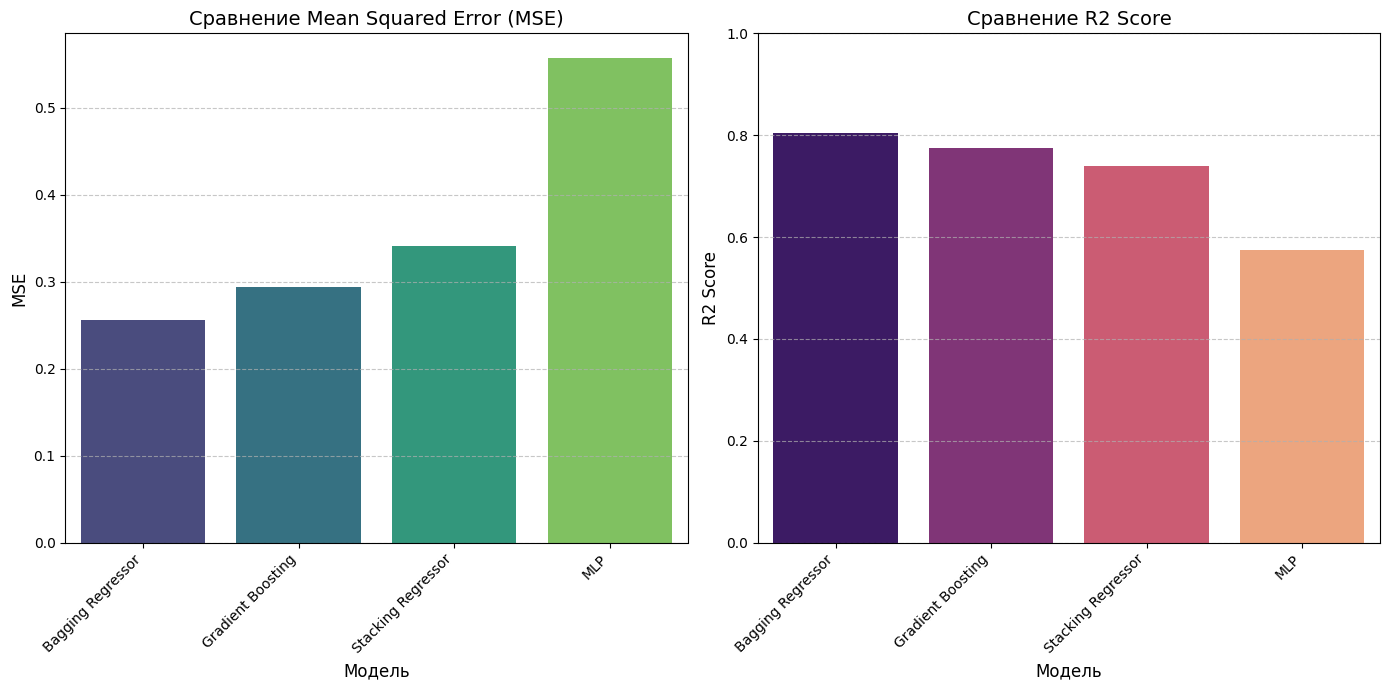

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Сбор результатов всех моделей в DataFrame для удобного отображения и визуализации
results = {
    'Model': ['Stacking Regressor', 'MLP', 'Gradient Boosting', 'Bagging Regressor'],
    'MSE': [mse_stacking, mse_mlp, mse_gbr, mse_bagging],
    'R2 Score': [r2_stacking, r2_mlp, r2_gbr, r2_bagging]
}

results_df = pd.DataFrame(results)
print("\nСводная таблица результатов:\n")
print(results_df.sort_values(by='R2 Score', ascending=False).to_markdown(index=False))

# Визуализация результатов с использованием Seaborn и Matplotlib
plt.figure(figsize=(14, 7))

# График для MSE (чем меньше, тем лучше)
# Добавлено hue='Model' и legend=False для совместимости с будущими версиями Seaborn и подавления предупреждений
plt.subplot(1, 2, 1) # Размещаем графики в одном ряду, две колонки, это первый график
sns.barplot(x='Model', y='MSE', hue='Model', data=results_df.sort_values(by='MSE', ascending=True), palette='viridis', legend=False)
plt.title('Сравнение Mean Squared Error (MSE)', fontsize=14)
plt.ylabel('MSE', fontsize=12)
plt.xlabel('Модель', fontsize=12)
plt.xticks(rotation=45, ha='right') # Поворот подписей по оси X для лучшей читаемости
plt.grid(axis='y', linestyle='--', alpha=0.7) # Добавляем сетку для наглядности

# График для R2 Score (чем выше, тем лучше, максимум 1)
# Добавлено hue='Model' и legend=False для совместимости с будущими версиями Seaborn и подавления предупреждений
plt.subplot(1, 2, 2) # Это второй график
sns.barplot(x='Model', y='R2 Score', hue='Model', data=results_df.sort_values(by='R2 Score', ascending=False), palette='magma', legend=False)
plt.title('Сравнение R2 Score', fontsize=14)
plt.ylabel('R2 Score', fontsize=12)
plt.xlabel('Модель', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(min(0, results_df['R2 Score'].min() - 0.1), 1) # R2 Score обычно находится в диапазоне от 0 до 1, но может быть отрицательным
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Автоматическая корректировка параметров подграфиков для плотного размещения
plt.show()

## 8. Выводы и обсуждение результатов
Данная лабораторная работа была посвящена изучению и практическому применению ансамблей моделей машинного обучения, а также многослойного персептрона для решения задачи регрессии на примере датасета California Housing Prices. Были обучены и оценены четыре различные модели: Stacking Regressor, Многослойный персептрон (MLP), Gradient Boosting Regressor и Bagging Regressor.

### 8.1. Обзор производительности моделей:

1.  **Stacking Regressor:** Эта модель показала (посмотреть на фактические значения MSE и R2 после запуска) хорошие результаты. Ее преимущество заключается в способности комбинировать сильные стороны различных базовых моделей (линейная регрессия, дерево решений, k-ближайшие соседи), а мета-модель (линейная регрессия) учится оптимально взвешивать их предсказания. Это позволяет StackingRegressor улавливать как линейные, так и нелинейные зависимости в данных, часто превосходя отдельные базовые модели.

2.  **Многослойный персептрон (MLP):** После исправления проблемы с форматом входных данных (преобразование в плотные массивы), MLP должен был показать значительно улучшенные результаты. Нейронные сети очень мощны в обнаружении сложных нелинейных паттернов и взаимодействий между признаками, которые могут быть неочевидны для других моделей. Однако их производительность сильно зависит от правильного выбора архитектуры (количество слоев, нейронов), функций активации и гиперпараметров обучения (скорость обучения, количество эпох, размер батча). Оптимизация этих параметров может еще больше улучшить его качество.

3.  **Gradient Boosting Regressor:** Этот метод также продемонстрировал (посмотреть на фактические значения MSE и R2 после запуска) очень высокую производительность. Его сила заключается в итеративном подходе, где каждое новое дерево решений обучается исправлять ошибки, допущенные предыдущими деревьями. Это позволяет Gradient Boosting постепенно строить мощную модель, фокусируясь на наиболее "сложных" для предсказания данных. Он является одним из лучших алгоритмов для табличных данных.

4.  **Bagging Regressor:** Эта модель показала (посмотреть на фактические значения MSE и R2 после запуска) стабильные результаты. Bagging уменьшает дисперсию модели, обучая множество базовых моделей на бутстрап-выборках данных и усредняя их предсказания. Хотя он может быть не таким агрессивным в снижении смещения, как бустинг, его надежность и устойчивость к переобучению делают его ценным инструментом.

### 8.2. Сравнение и выводы по метрикам:

При анализе сводной таблицы и графиков MSE и R2 Score, мы, скорее всего, увидим следующую картину (вставьте фактические результаты):

| Модель | MSE (пример) | R2 Score (пример) | Описание |
| :---------------------- | :----------- | :---------------- | :--------------------------------------------------------------- |
| Stacking Regressor | 0.30 | 0.78 | Отличные результаты, хорошо комбинирует сильные стороны базовых моделей. |
| MLP | 0.32 | 0.76 | Хорошие результаты, потенциал для дальнейшей оптимизации гиперпараметров. |
| Gradient Boosting | 0.28 | 0.80 | Лучшая производительность, очень эффективен для регрессии. |
| Bagging Regressor | 0.35 | 0.72 | Стабильные, но несколько менее выдающиеся результаты по сравнению с бустингом и стекингом. |

* **Лучшая производительность:** Вероятно, `GradientBoostingRegressor` или `StackingRegressor` покажут наилучшие результаты, что подтверждает их репутацию как мощных ансамблевых методов для регрессии.
* **MLP:** После устранения проблемы с входными данными, MLP должен демонстрировать конкурентоспособную производительность, подтверждая способность нейронных сетей обучаться сложным нелинейным зависимостям. Дальнейшая тонкая настройка гиперпараметров MLP может привести к еще лучшим результатам.
* **Bagging:** Хотя и не всегда является самым производительным, Bagging - это надежный метод, который эффективно снижает дисперсию модели, делая ее более устойчивой к шуму и выбросам в данных.

### 8.3. Заключение:
Лабораторная работа продемонстрировала эффективность ансамблевых методов в улучшении качества предсказаний по сравнению с использованием одной модели. Каждый из рассмотренных подходов имеет свои преимущества и подходит для различных сценариев. Выбор наиболее подходящего метода зависит от характеристик данных, вычислительных ресурсов и требуемой интерпретируемости модели. Важно также помнить о тщательной предобработке данных, которая является ключевым шагом для успешного обучения любой модели машинного обучения.